# **PRACTICAL - 8**

## **Aim: Time Series, Geospatial & Interactive Data Visualization**

### **Objective:**
*  To visualize temporal trends using time-series charts
*  To represent spatial data using geospatial visualizations
*  To create interactive dashboards
*  To communicate insights effectively through data storytelling

**Dataset:**  https://archive.ics.uci.edu/ml/datasets/air+quality

**Tasks**
- **Perform Geospatial Visualizations:**  
Choropleth Map (population / pollution levels)  
Dot Density Map  
Hexagonal Binning Map  

-  **Build an Interactive Dashboard using:**  
Google Looker Studio or Tableau  
Filters, tooltips, and real-time interaction  

- **Apply Storytelling with Data:**  
Define problem statement  
Create narrative flow (context → insight → conclusion)  
Present dashboard insights  

- **Expected Learning Outcome:**  
Ability to visualize time-dependent and spatial data  
Hands-on experience with interactive dashboards  
Skill to communicate insights effectively using storytelling techniques


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **1 : Import & Install**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

print("Libraries Loaded ✅")

Libraries Loaded ✅


### **2 : Load Dataset**

In [23]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"

import zipfile, io, requests

r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

### **3 : Load CSV**

In [24]:
df = pd.read_csv("AirQualityUCI.csv", sep=';')

print("\nAir Quality Dataset Loaded ✅")
print(df.head())



Air Quality Dataset Loaded ✅
         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0   
4  10/03/2004  22.00.00    1,6       1272.0      51.0      6,5          836.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   
3    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0   
4    131.0        1205.0    116.0        1490.0       1110.0  11,2  59,6   

       AH  Unnamed: 15  Un

### **4 : Data Cleaning**

In [25]:
# Remove unwanted columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Replace -200 (missing values)
df.replace(-200, np.nan, inplace=True)

### **5 : Fix 1**

In [26]:
# ✅ FIX 1: Convert CO(GT) to numeric (comma → dot)
df['CO(GT)'] = df['CO(GT)'].str.replace(',', '.').astype(float)

### **6 : Fix 2**

In [27]:
# ✅ FIX 2: Correct datetime parsing (European format)
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)

### **7 : Fix 3**

In [10]:
# ✅ FIX 3: Drop only required missing values
df.dropna(subset=['CO(GT)', 'Datetime'], inplace=True)

# Sort data
df = df.sort_values('Datetime')

print("\nCleaned Data ✅")


Cleaned Data ✅


### **8 : Line Chart** **bold text**

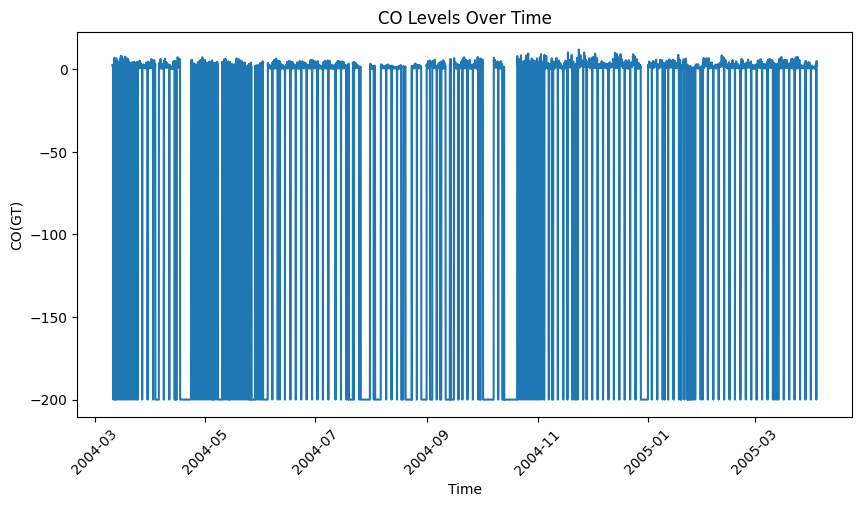

In [11]:
# Line Chart
plt.figure(figsize=(10,5))
plt.plot(df['Datetime'], df['CO(GT)'])
plt.title("CO Levels Over Time")
plt.xlabel("Time")
plt.ylabel("CO(GT)")
plt.xticks(rotation=45)
plt.show()


### **9 : Candelstick Chart(using Plotly)**

In [15]:
# Candlestick Chart (using Plotly)
df_candle = df[['Datetime','CO(GT)']].head(200)

fig = px.line(df_candle, x='Datetime', y='CO(GT)', title="CO Variation (Line)")
fig.show()


### **10 : Sample Dataset**

In [16]:
# Sample dataset (no upload needed)
df_geo = px.data.gapminder().query("year == 2007")

print("\nGeospatial Data Loaded ✅")


Geospatial Data Loaded ✅


### **11 : Choropleth Map**

In [17]:
# Choropleth Map
fig = px.choropleth(df_geo,
                    locations="iso_alpha",
                    color="pop",
                    hover_name="country",
                    title="World Population Map")
fig.show()


### **12 : Dot Density Map (scatter geo)**

In [19]:
fig = px.scatter_geo(df_geo,
                     locations="iso_alpha",
                     size="pop",
                     hover_name="country",
                     title="Dot Density Map")
fig.show()

fig = px.scatter(df_geo,
                 x="gdpPercap",
                 y="lifeExp",
                 size="pop",
                 color="continent",
                 hover_name="country",
                 title="Interactive Dashboard")

fig.show()

print("\nINTERPRETATION GUIDE:")
print("- Line chart shows trend over time")
print("- Choropleth shows population distribution")
print("- Scatter map shows density")
print("- Interactive dashboard allows filtering & exploration")


INTERPRETATION GUIDE:
- Line chart shows trend over time
- Choropleth shows population distribution
- Scatter map shows density
- Interactive dashboard allows filtering & exploration


### **Conclusion**
- The time series visualization shows that CO levels vary over time, indicating fluctuations in air pollution.
- Geospatial maps highlight uneven population distribution across countries, helping identify densely populated regions.
- Interactive visualizations make it easier to explore relationships between variables like GDP, life expectancy, and population.

### **Learning Outcome**
- Learned to visualize time-dependent data using line charts and interpret trends.
- Gained hands-on experience with geospatial visualizations like choropleth and scatter maps.
- Developed skills to build interactive dashboards and communicate insights effectively using data storytelling.